In [22]:
%load_ext autoreload
%autoreload 2

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '..'))

from symlie.misc.viz import plot2d
# from symlie.misc.utils_results import pivot, assert_columns_same, get_and_check_Ps, stringify_dict, aggregate_dataset, plot_best, return_table, plot_pivot
from symlie.misc.utils_results import get_and_check_Ps, aggregate_dataset, plot_best, return_table, assert_columns_same
from symlie.misc.wandb import update_results_df, get_inspect_df
from symlie.model.setup import load_P_pred

from sympdee.sympde.viz.general_plots import savefig

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
# Select dataframe to analyze
check_df = 'results'
reload = False

# check_df = 'inspect'
# reload = True

match check_df:
    case 'results':
        if reload:
            update_results_df()
        df = pd.read_pickle('../logs/store/results_df.pkl')
        plot_single_pivot = False
    case 'inspect':
        df_inspect = get_inspect_df(reload = reload)
        df = df_inspect
        plot_single_pivot = True

print(df.shape)

(579, 49)


In [24]:
# Select step to analyze
step = 1
# step = 2

datasets_new = [
    'sine1d',
    'sine2d',
    'flower',
    'mnist',
    'noise'
    'sine1d-noise',
]

datasets_inspect = [
    # 'sine1d-noise',
    # 'sine1dlayers',
    # 'sine1dtwo-hparam',
    # 'noise',
    'sine1d-noise',
]
datasets = {'results' : datasets_new, 'inspect' : datasets_inspect}[check_df]

default_log = [
    'sine2d',
    # 'flower',
    'noise',
    # 'sine1d-noise',
]

group_params = ['eps_mult', 'noise_std']
# hyper_params  = ['n_train', 'lr', 'svd_rank', 'net'] if step == 2 else ['lr', 'svd_rank']
hyper_params  = ['n_train', 'lr', 'net'] if step == 2 else ['lr', 'svd_rank']
# hyper_params  = ['n_train', 'lr', 'net'] if step == 2 else ['lr']
# hyper_params  = ['n_train', 'lr', 'net', 'svd_rank'] if step == 2 else ['lr', 'svd_rank']

d_pivots, ddd, ddd_mean, ddd_std, mins = aggregate_dataset(
# d = aggregate_dataset(
    datasets=datasets,
    df = df,
    step = step,
    group_params = group_params,
    hyper_params = hyper_params,
    check_df=check_df,
    default_log=default_log,
    plot_single_pivot=False,
)

# d = d.mean().unstack().reset_index(level = 0, drop = True)

ddd_mean

dataset_name='sine1d', group=('[0, 0, 1, 0]', '0.5'), hparams_min=('test_loss', 0.001, nan)
dataset_name='sine2d', group=('[0, 0, 1, 1]', '0.1'), hparams_min=('test_loss', 0.001, nan)
dataset_name='sine2d', group=('[0, 1, 1, 1]', '0.1'), hparams_min=('test_loss', 0.001, nan)
dataset_name='flower', group=('[0, 0, 1, 1]', '0.0'), hparams_min=('test_loss', 0.01, nan)
dataset_name='flower', group=('[0, 0, 1, 1]', '0.1'), hparams_min=('test_loss', 0.01, nan)
dataset_name='flower', group=('[0, 1, 1, 1]', '0.0'), hparams_min=('test_loss', 0.01, nan)
dataset_name='flower', group=('[0, 1, 1, 1]', '0.1'), hparams_min=('test_loss', 0.01, nan)
dataset_name='mnist', group=('[0, 1, 1, 1]', '0.0'), hparams_min=('test_loss', 0.01, nan)
dataset_name='mnist', group=('[0, 1, 1, 1]', '0.1'), hparams_min=('test_loss', 0.01, nan)


test_loss                    
lr                                      0.001      0.01       0.1
svd_rank                                  NaN       NaN       NaN
dataset_name eps_mult     noise_std                              
sine1d       [0, 0, 1, 0] 0.5        0.000002  0.000018  0.000020
sine2d       [0, 0, 1, 1] 0.1        0.000729  0.001301  0.001162
             [0, 1, 1, 1] 0.1        0.000742  0.001332  0.001167
flower       [0, 0, 1, 1] 0.0        0.002449  0.002165  0.002498
                          0.1        0.002779  0.002468  0.002746
             [0, 1, 1, 1] 0.0        0.002546  0.002333  0.002530
                          0.1        0.002859  0.002648  0.002807
mnist        [0, 1, 1, 1] 0.0        0.006028  0.003762  0.003992
                          0.1        0.006638  0.004369  0.004589

In [25]:
# df[
#     (df['lr'] == 0.001) &
#     (df['net'] == 'TrainP') & 
#     (df['n_train'] == 1000) &
# ]

In [26]:
def select_dict_with_id(d: dict, id: int = 0):
    k = list(d.keys())[id]
    return d[k], k


ddd_mean

test_loss                    
lr                                      0.001      0.01       0.1
svd_rank                                  NaN       NaN       NaN
dataset_name eps_mult     noise_std                              
sine1d       [0, 0, 1, 0] 0.5        0.000002  0.000018  0.000020
sine2d       [0, 0, 1, 1] 0.1        0.000729  0.001301  0.001162
             [0, 1, 1, 1] 0.1        0.000742  0.001332  0.001167
flower       [0, 0, 1, 1] 0.0        0.002449  0.002165  0.002498
                          0.1        0.002779  0.002468  0.002746
             [0, 1, 1, 1] 0.0        0.002546  0.002333  0.002530
                          0.1        0.002859  0.002648  0.002807
mnist        [0, 1, 1, 1] 0.0        0.006028  0.003762  0.003992
                          0.1        0.006638  0.004369  0.004589

In [27]:
# d = list(d_pivots.values())[0]['d_pivot']
# d = d.iloc[:, d.columns.get_level_values(4) == 'Trained with noise']
# d = d.droplevel(4, axis = 1)

# d = d.min().unstack().reset_index(level = 0, drop = True)

# d.plot(kind = 'bar')

In [28]:
if step == 2:
    plot_best(ddd_mean, ddd_std)
return_table(df, step, group_params, hyper_params)

test_loss                          \
lr                                        0.001                           
svd_rank                                   3.0                            
seed                                          1             2         3   
data_dir       eps_mult     noise_std                                     
../data/MNIST  [0, 1, 1, 1] 0.0             NaN           NaN       NaN   
                            0.1             NaN           NaN       NaN   
../data/flower [0, 0, 1, 1] 0.0             NaN           NaN       NaN   
                            0.1             NaN           NaN       NaN   
               [0, 1, 1, 1] 0.0             NaN           NaN       NaN   
                            0.1             NaN           NaN       NaN   
../data/noise  [0, 0, 1, 0] 1.0        0.076846  2.919860e-14  0.033282   
               [0, 0, 1, 1] 1.0             NaN           NaN       NaN   
               [0, 1, 1, 1] 1.0             NaN           NaN       NaN   
../data/sine1d [0, 0, 1, 0] 0.5             NaN           NaN       NaN   
../data/sine2d [0, 0, 1, 1] 0.1             NaN           NaN       NaN   
               [0, 1, 1, 1] 0.1             NaN           NaN       NaN   

                                                                             \
lr                                                                            
svd_rank                                       7.0                            
seed                                              1             2         3   
data_dir       eps_mult     noise_std                                         
../data/MNIST  [0, 1, 1, 1] 0.0                 NaN           NaN       NaN   
                            0.1                 NaN           NaN       NaN   
../data/flower [0, 0, 1, 1] 0.0                 NaN           NaN       NaN   
                            0.1                 NaN           NaN       NaN   
               [0, 1, 1, 1] 0.0                 NaN           NaN       NaN   
                            0.1                 NaN           NaN       NaN   
../data/noise  [0, 0, 1, 0] 1.0        1.788519e-10  2.148148e-07  0.068766   
               [0, 0, 1, 1] 1.0                 NaN           NaN       NaN   
               [0, 1, 1, 1] 1.0                 NaN           NaN       NaN   
../data/sine1d [0, 0, 1, 0] 0.5                 NaN           NaN       NaN   
../data/sine2d [0, 0, 1, 1] 0.1                 NaN           NaN       NaN   
               [0, 1, 1, 1] 0.1                 NaN           NaN       NaN   

                                                                   \
lr                                                                  
svd_rank                                       14.0                 
seed                                              1             2   
data_dir       eps_mult     noise_std                               
../data/MNIST  [0, 1, 1, 1] 0.0                 NaN           NaN   
                            0.1                 NaN           NaN   
../data/flower [0, 0, 1, 1] 0.0                 NaN           NaN   
                            0.1                 NaN           NaN   
               [0, 1, 1, 1] 0.0                 NaN           NaN   
                            0.1                 NaN           NaN   
../data/noise  [0, 0, 1, 0] 1.0        4.305833e-07  1.852233e-08   
               [0, 0, 1, 1] 1.0                 NaN           NaN   
               [0, 1, 1, 1] 1.0                 NaN           NaN   
../data/sine1d [0, 0, 1, 0] 0.5                 NaN           NaN   
../data/sine2d [0, 0, 1, 1] 0.1                 NaN           NaN   
               [0, 1, 1, 1] 0.1                 NaN           NaN   

                                                                   ...  \
lr                                                                 ...   
svd_rank                                                     30.0  ...   
seed                  

# Map

In [29]:
assert step == 1

In [30]:
def filter_on_tags(df, tags):
    return df[df['tags'].astype(str).str.contains('|'.join(tags))]

In [31]:
df_map = pd.read_pickle('../logs/store/map_df.pkl')

df_map_sync = filter_on_tags(df_map, tags = ['sine1d', 'noise'])
df_map_sync = df_map_sync.reset_index(drop=True)
df_map_sync

,run_id,tags,data_kwargs,transform_kwargs,seed,data_dir,svd_rank
0,3gi8lu9g,"['new', 'sine1d']","{'y_low': 1, 'y_high': 3, 'grid_size': (1, 7),...","{'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip'...",3,../data/sine1d,NaN
1,lh3nnnij,"['new', 'sine1d']","{'y_low': 1, 'y_high': 3, 'grid_size': (1, 7),...","{'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip'...",2,../data/sine1d,NaN
2,cpw6d6pz,"['new', 'sine1d']","{'y_low': 1, 'y_high': 3, 'grid_size': (1, 7),...","{'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip'...",1,../data/sine1d,NaN
3,vjewun0b,"['hparam', 'noise']","{'grid_size': (1, 7), 'noise_std': 1}","{'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip'...",3,../data/noise,NaN
4,g41hidqj,"['hparam', 'noise']","{'grid_size': (1, 7), 'noise_std': 1}","{'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip'...",2,../data/noise,NaN
5,xxidyaps,"['hparam', 'noise']","{'grid_size': (1, 7), 'noise_std': 1}","{'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip'...",1,../data/noise,NaN
6,5qbdclqh,"['new', 'noise']","{'grid_size': (7, 7), 'noise_std': 1}","{'eps_mult': [0.0, 0.0, 1.0, 1.0], 'only_flip'...",3,../data/noise,NaN
7,jb4gxwpb,"['new', 'noise']","{'grid_size': (7, 7), 'noise_std': 1}","{'eps_mult': [0.0, 0.0, 1.0, 1.0], 'only_flip'...",2,../data/noise,NaN
8,o7w74teb,"['new', 'noise']","{'grid_size': (7, 7), 'noise_std': 1}","{'eps_mult': [0.0, 0.0, 1.0, 1.0], 'only_flip'...",1,../data/noise,NaN
9,6pb0nn34,"['new', 'noise']","{'grid_size': (7, 7), 'noise_std': 1}","{'eps_mult': [0.0, 1.0, 1.0, 1.0], 'only_flip'...",3,../data/noise,NaN


In [32]:
sync_run_ids = list(df_map_sync['run_id'].values)

store_dir = '../logs/store'
# write the run_ids to a txt file
with open(os.path.join(store_dir, 'sync_run_ids.txt'), 'w') as f:
    f.write(f"{{{','.join(sync_run_ids)}}}")

# Let's check P's

In [33]:
df

,lr,net,bias,name,seed,tags,test,A_low,n_val,train,...,args_processed,do_return_model,n_hidden_layers,transform_kwargs,use_P_from_noise,persistent_workers,run_name,test_loss,n_classes,svd_rank
0,0.010,TrainP,False,None,3,"['new', 'noise']",True,NaN,1000,True,...,True,False,1.0,"{'eps_mult': [0, 1, 1, 1], 'only_flip': False}",False,True,dandy-donkey-1960,6.474450e-05,NaN,NaN
1,0.001,TrainP,False,None,3,"['new', 'noise']",True,NaN,1000,True,...,True,False,1.0,"{'eps_mult': [0, 1, 1, 1], 'only_flip': False}",False,True,swept-lion-1959,3.812419e-02,NaN,NaN
2,0.100,TrainP,False,None,3,"['new', 'noise']",True,NaN,1000,True,...,True,False,1.0,"{'eps_mult': [0, 1, 1, 1], 'only_flip': False}",False,True,atomic-planet-1958,1.422213e-07,NaN,NaN
3,0.001,TrainP,False,None,2,"['new', 'noise']",True,NaN,1000,True,...,True,False,1.0,"{'eps_mult': [0, 1, 1, 1], 'only_flip': False}",False,True,royal-mountain-1957,3.862118e-02,NaN,NaN
4,0.100,TrainP,False,None,2,"['new', 'noise']",True,NaN,1000,True,...,True,False,1.0,"{'eps_mult': [0, 1, 1, 1], 'only_flip': False}",False,True,glamorous-snowflake-1955,1.425501e-07,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,0.100,TrainP,False,None,1,"['inspect', 'new', 'noise', 'svd']",True,None,1000,True,...,True,False,1.0,"{'eps_mult': [0, 0, 1, 0], 'only_flip': False}",False,True,eager-firefly-2213,1.208998e-14,None,14.0
575,0.010,TrainP,False,None,1,"['inspect', 'new', 'noise', 'svd']",True,None,1000,True,...,True,False,1.0,"{'eps_mult': [0, 0, 1, 0], 'only_flip': False}",False,True,toasty-paper-2213,7.349598e-02,None,3.0
576,0.100,TrainP,False,None,1,"['inspect', 'new', 'noise', 'svd']",True,None,1000,True,...,True,False,1.0,"{'eps_mult': [0, 0, 1, 0], 'only_flip': False}",False,True,pleasant-pine-2213,9.551645e-12,None,30.0
577,0.100,TrainP,False,None,1,"['inspect', 'new', 'noise', 'svd']",True,None,1000,True,...,True,False,1.0,"{'eps_mult': [0, 0, 1, 0], 'only_flip': False}",False,True,devoted-firefly-2212,4.830418e-15,None,7.0


In [34]:
# Select df
d = df_map_sync
# d = df_map
# d = df

# Filter d
d = filter_on_tags(d, tags = ['noise'])
transform_kwargs = {'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip': False}
# d = d[d['transform_kwargs'] == transform_kwargs]
# # d = d[d['svd_rank'] == 3]
d = d[d['svd_rank'].isna()]
# map_kwargs = assert_columns_same(d, ['data_kwargs', 'transform_kwargs', 'data_dir', 'svd_rank'])
# print(f'map_kwargs = {map_kwargs}')

# seeds = d['seed'].unique()
# n_d = len(d)
# assert len(seeds) == n_d, f'seeds={seeds}, n_d={n_d}'
# print(f'seeds={seeds}')

d_noise = d
seeds = d_noise['seed'].unique()
assert len(seeds) == 3
d_noise

,run_id,tags,data_kwargs,transform_kwargs,seed,data_dir,svd_rank
3,vjewun0b,"['hparam', 'noise']","{'grid_size': (1, 7), 'noise_std': 1}","{'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip'...",3,../data/noise,NaN
4,g41hidqj,"['hparam', 'noise']","{'grid_size': (1, 7), 'noise_std': 1}","{'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip'...",2,../data/noise,NaN
5,xxidyaps,"['hparam', 'noise']","{'grid_size': (1, 7), 'noise_std': 1}","{'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip'...",1,../data/noise,NaN
6,5qbdclqh,"['new', 'noise']","{'grid_size': (7, 7), 'noise_std': 1}","{'eps_mult': [0.0, 0.0, 1.0, 1.0], 'only_flip'...",3,../data/noise,NaN
7,jb4gxwpb,"['new', 'noise']","{'grid_size': (7, 7), 'noise_std': 1}","{'eps_mult': [0.0, 0.0, 1.0, 1.0], 'only_flip'...",2,../data/noise,NaN
8,o7w74teb,"['new', 'noise']","{'grid_size': (7, 7), 'noise_std': 1}","{'eps_mult': [0.0, 0.0, 1.0, 1.0], 'only_flip'...",1,../data/noise,NaN
9,6pb0nn34,"['new', 'noise']","{'grid_size': (7, 7), 'noise_std': 1}","{'eps_mult': [0.0, 1.0, 1.0, 1.0], 'only_flip'...",3,../data/noise,NaN
10,dgmb6jhh,"['new', 'noise']","{'grid_size': (7, 7), 'noise_std': 1}","{'eps_mult': [0.0, 1.0, 1.0, 1.0], 'only_flip'...",2,../data/noise,NaN
11,vhgrhmcw,"['new', 'noise']","{'grid_size': (7, 7), 'noise_std': 1}","{'eps_mult': [0.0, 1.0, 1.0, 1.0], 'only_flip'...",1,../data/noise,NaN


In [35]:
noise_id_lookup = {
    'T(1)' : ['vjewun0b', 'g41hidqj', 'xxidyaps'],
    'SO(2)': ['5qbdclqh', 'jb4gxwpb', 'o7w74teb'],
    'SE(2)': ['6pb0nn34', 'dgmb6jhh', 'vhgrhmcw'],
}
noise_id_lookup = pd.DataFrame(noise_id_lookup)


seed = 1

run_ids = noise_id_lookup.iloc[seed-1].values
Ps = [load_P_pred(run_id) for run_id in run_ids]

Ps

[tensor([[-0.6260,  0.1420, -0.4238,  ...,  0.2007, -0.1293, -1.3056],
         [-0.3311, -1.0058, -0.3862,  ..., -0.2246,  1.7285, -0.7841],
         [ 1.0056,  0.1577, -0.3774,  ..., -0.8366,  0.6145,  1.5486],
         ...,
         [ 1.9016, -1.0414,  2.2540,  ...,  1.5091, -1.2168, -0.7416],
         [-0.4412, -0.4016,  1.1439,  ..., -1.4029,  1.7255, -0.7884],
         [-0.7839,  0.1855, -0.5394,  ...,  0.2415, -0.1579, -1.6246]]),
 tensor([[-18.8328,  21.5609,  -8.2685,  ...,  30.8548,  21.6552, -21.5293],
         [ -4.0382,  -4.0180,  20.3288,  ...,  17.1323,  20.3998, -26.6093],
         [ 15.8781,  -4.9977,  15.1942,  ...,  -7.2923, -22.6324,   5.2202],
         ...,
         [-22.4715,   8.5013,   2.3829,  ...,   3.1958, -21.0265,   0.7365],
         [ 22.7938,  -3.8209, -21.2411,  ...,  16.3582,  21.6621, -14.9162],
         [-19.3432,  21.7223,  -7.8870,  ...,  30.5144,  21.8230, -21.7396]]),
 tensor([[-30.3005,  -8.2389,   6.4022,  ...,  27.8728,   8.0764, -18.3269],
   

/Users/elias/EliasMBA/Projects/Uni/SymPDE/notebooks_symlie/../sympdee/sympde/viz/general_plots.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(os.path.join(path, subdir, f'{name}.png'), bbox_inches=bbox_inches, **kwargs)
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


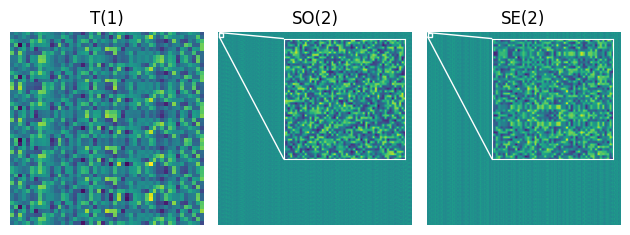

In [36]:
from symlie.model.networks.linear import LinearP
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

def axin(ax, x, zoom = 1, lims = (0, 10)):
    axins = zoomed_inset_axes(ax, zoom, loc=1)
    axins.imshow(x)
    axins.set_xlim(*lims)
    axins.set_ylim(*lims)

    axins.tick_params(color='white', labelcolor='white')
    for spine in axins.spines.values():
        spine.set_edgecolor('white')

    mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="1.")
    axins.set_xticks([])
    axins.set_yticks([])

fig, axs = plt.subplots(1, 3, tight_layout = True)

l = 50
for i, (ax, P) in enumerate(zip(axs, Ps)):
    ax.imshow(P)
    ax.set_axis_off()
    if i > 0:
        axin(ax, P, zoom = 30, lims = (10, 60))
    
    ax.set_title(noise_id_lookup.keys()[i])
savefig(fig, 'trainP_noise', '5-experiments')

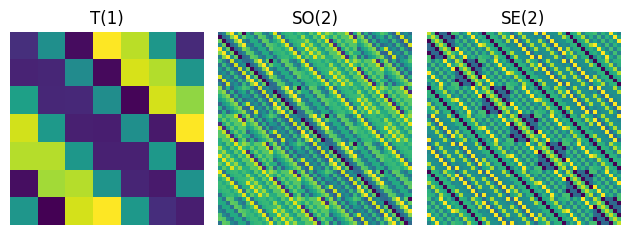

In [37]:
fig, axs = plt.subplots(1, 3, tight_layout = True)

for i, (ax, P) in enumerate(zip(axs, Ps)):
    n_f = np.sqrt(P.shape[0]).astype(int)  

    l = LinearP(in_features=n_f, out_features=n_f, bias = False)
    weight = l.weight

    w_equiv = (P @ weight.flatten()).reshape(weight.shape).detach()


    ax.imshow(w_equiv)
    ax.set_axis_off()
    
    ax.set_title(noise_id_lookup.keys()[i])
# savefig(fig, 'trainP_noise_equiv', '5-experiments')


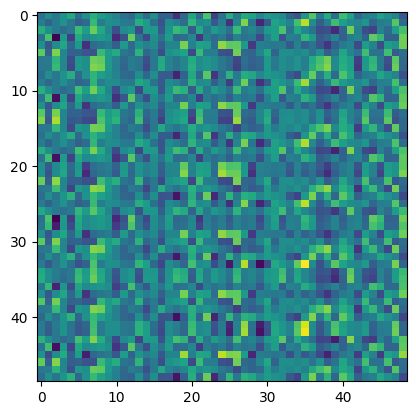

7


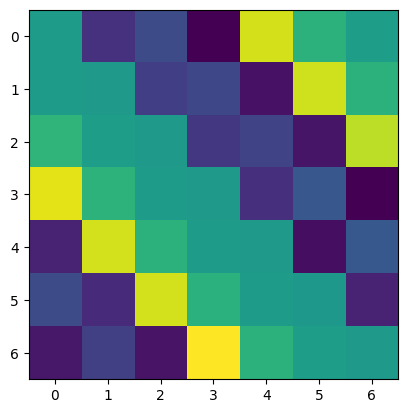

In [38]:
import torch

run_id = 'vjewun0b'
p = load_P_pred(run_id)
plt.imshow(p)
plt.show()

n_f = np.sqrt(p.shape[0]).astype(int)  
print(n_f)
l = linear = LinearP(in_features=n_f, out_features=n_f, bias = False)

# x = torch.randn((1, 1, n_f))
# l(x, P=p)

weight = l.weight
# linear.weight.data = torch.arange(linear.out_features*linear.in_features).reshape(linear.out_features, linear.in_features).float()
w_equiv = (p @ weight.flatten()).reshape(weight.shape).detach()
plt.imshow(w_equiv)
plt.show()

3
map_kwargs = {'data_kwargs': {'grid_size': (1, 7), 'noise_std': 1}, 'transform_kwargs': {'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip': False}, 'data_dir': '../data/noise', 'svd_rank': 3.0}
seeds=[3 2 1]
Found run_id uutj0wk7
Found run_id ghhrf8d0
Found run_id ep9fxvi5


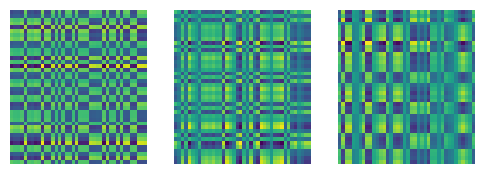

14
map_kwargs = {'data_kwargs': {'grid_size': (1, 7), 'noise_std': 1}, 'transform_kwargs': {'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip': False}, 'data_dir': '../data/noise', 'svd_rank': 14.0}
seeds=[3 2 1]
Found run_id 04b8dk60
Found run_id 7svolu0i
Found run_id n2s6xsu9


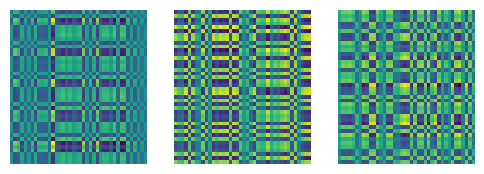

30
map_kwargs = {'data_kwargs': {'grid_size': (1, 7), 'noise_std': 1}, 'transform_kwargs': {'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip': False}, 'data_dir': '../data/noise', 'svd_rank': 30.0}
seeds=[3 2 1]
Found run_id 4tf7fy4o
Found run_id 8l7slkwl
Found run_id 1glxxvmq


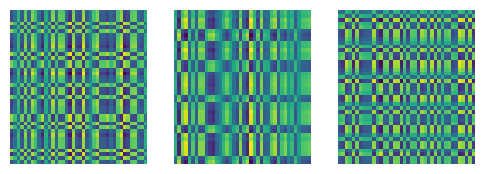

In [39]:
svd_ranks = [3, 14, 30]
P_svds = []

for svd_rank in svd_ranks:
    print(svd_rank)

    df_map = pd.read_pickle('../logs/store/map_df.pkl')

    df_map_sync = filter_on_tags(df_map, tags = ['sine1d', 'noise'])
    df_map_sync = df_map_sync.reset_index(drop=True)

    # Select df
    d = df_map_sync
    # d = df_map
    # d = df

    # Filter d
    d = filter_on_tags(d, tags = ['noise'])
    transform_kwargs = {'eps_mult': [0.0, 0.0, 1.0, 0.0], 'only_flip': False}
    d = d[d['transform_kwargs'] == transform_kwargs]
    d = d[d['svd_rank'] == svd_rank]
    map_kwargs = assert_columns_same(d, ['data_kwargs', 'transform_kwargs', 'data_dir', 'svd_rank'])
    print(f'map_kwargs = {map_kwargs}')

    seeds = d['seed'].unique()
    n_d = len(d)
    assert len(seeds) == n_d, f'seeds={seeds}, n_d={n_d}'
    print(f'seeds={seeds}')

    Ps = get_and_check_Ps(seeds, map_kwargs, use_P_from_noise = False)
    # Ps = get_and_check_Ps([1], map_kwargs)
    plot2d(Ps, l = 2, max_grid = 40)

    P_svds.append(Ps[0])

P_svds = torch.stack(P_svds)

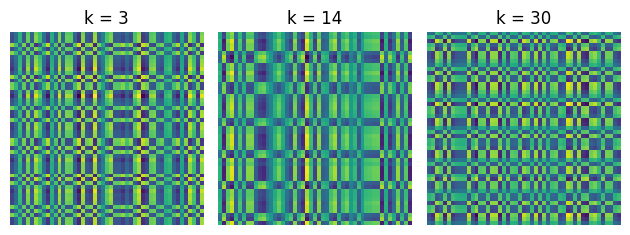

In [40]:
fig, axs = plt.subplots(1, 3, tight_layout = True)

l = 50
for i, (ax, P) in enumerate(zip(axs, Ps)):
    ax.imshow(P)
    ax.set_axis_off()
    ax.set_title(fr'k = {svd_ranks[i]}')
# savefig(fig, 'svd_trainP_noise', '5-experiments')

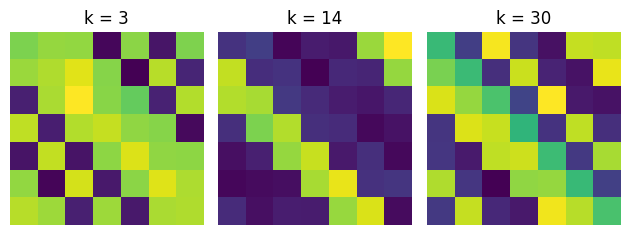

In [41]:
fig, axs = plt.subplots(1, 3, tight_layout = True)

for i, (ax, P) in enumerate(zip(axs, Ps)):
    n_f = np.sqrt(P.shape[0]).astype(int)  

    l = LinearP(in_features=n_f, out_features=n_f, bias = False)
    weight = l.weight

    w_equiv = (P @ weight.flatten()).reshape(weight.shape).detach()


    ax.imshow(w_equiv)
    ax.set_axis_off()
    
    ax.set_title(fr'k = {svd_ranks[i]}')
# savefig(fig, 'svd_trainP_noise_equiv', '5-experiments')


In [ ]:
import torch

from symlie.model.networks.implicit import LinearImplicit

In [ ]:
linear_implicit = LinearImplicit(
    in_features = 7, 
    out_features = 7,
    bias = False,
    hidden_implicit_layers = [49, 49],
)

implicit_statedict = torch.load('../logs/store/implicit_P/otnoxw0l.pt')
# linear_implicit.implicit_P.load_state_dict(implicit_statedict)

linear_implicit.eval()

NameError: name 'LinearImplicit' is not defined

In [ ]:
x = torch.randn((1,7))
x.shape

torch.Size([1, 7])

In [ ]:
linear_implicit(x)

tensor([[ 0.0080,  0.0532,  0.0000,  0.3132,  0.3418, -0.1157,  0.1974]],
       grad_fn=<MmBackward0>)